In [3]:
import time
import statistics
import heapq

def minimize_array_sum(arr, k):
    # Python has a min-heap, so store negative values
    heap = [-x for x in arr]
    heapq.heapify(heap)

    for _ in range(k):
        largest = -heapq.heappop(heap)

        reduced = (largest + 1) // 2

        heapq.heappush(heap, -reduced)

    return -sum(heap)


sizes = list(range(100, 10001, 500))
times = []
runs = 5

for n in sizes:
    # Fixed deterministic input
    arr = [(i * 37) % 10000 + 1 for i in range(n)]
    k = n

    measurements = []

    for _ in range(runs):
        start = time.perf_counter_ns()
        minimize_array_sum(arr, k)
        end = time.perf_counter_ns()

        measurements.append(end - start)

    times.append(statistics.median(measurements))

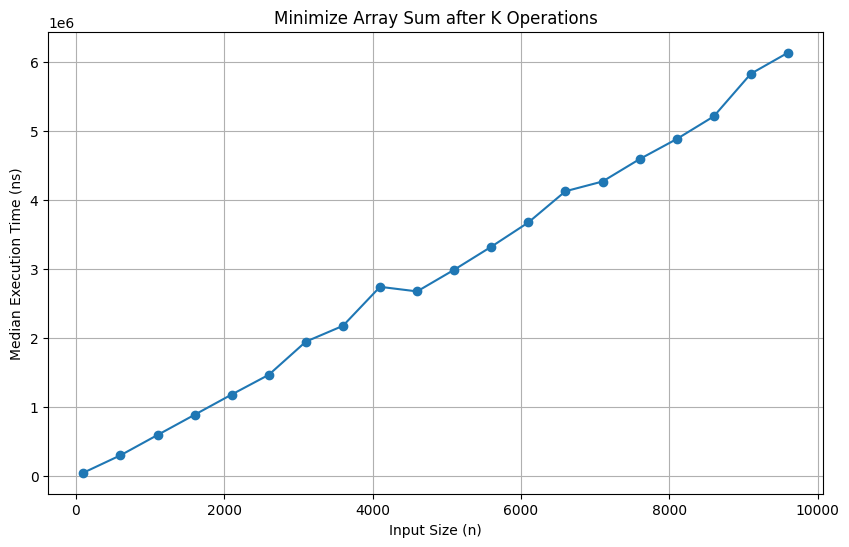

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title("Minimize Array Sum after K Operations")
plt.xlabel("Input Size (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)
plt.show()